# Frequency Analysis of Disaster Events

This notebook analyzes the frequency of disaster events including:
- Event frequency by hazard type
- Return period estimation
- Probability distribution fitting
- Temporal patterns and seasonality

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from config import PROCESSED_DATA_DIR, FIGURES_DIR, HAZARD_TYPES
from src.analysis import (calculate_event_frequency_by_period, fit_frequency_distribution,
                          analyze_temporal_trends, analyze_seasonal_patterns)
from src.visualization import plot_seasonal_heatmap
from src.risk_metrics import calculate_return_period

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Processed Data

In [2]:
data_file = PROCESSED_DATA_DIR / 'disaster_events_processed.csv'

if data_file.exists():
    df = pd.read_csv(data_file)
    print(f"Loaded {len(df)} processed records")
    print(f"Time period: {df['year'].min()} - {df['year'].max()}")
else:
    print(f"Processed data not found. Please run notebook 01 first.")
    df = None

Loaded 30 processed records
Time period: 2010 - 2023


## 2. Annual Event Frequency

Annual Event Frequency Statistics:
  Mean: 2.1 events/year
  Median: 2.0 events/year
  Std Dev: 0.4
  Min: 2 events/year
  Max: 3 events/year


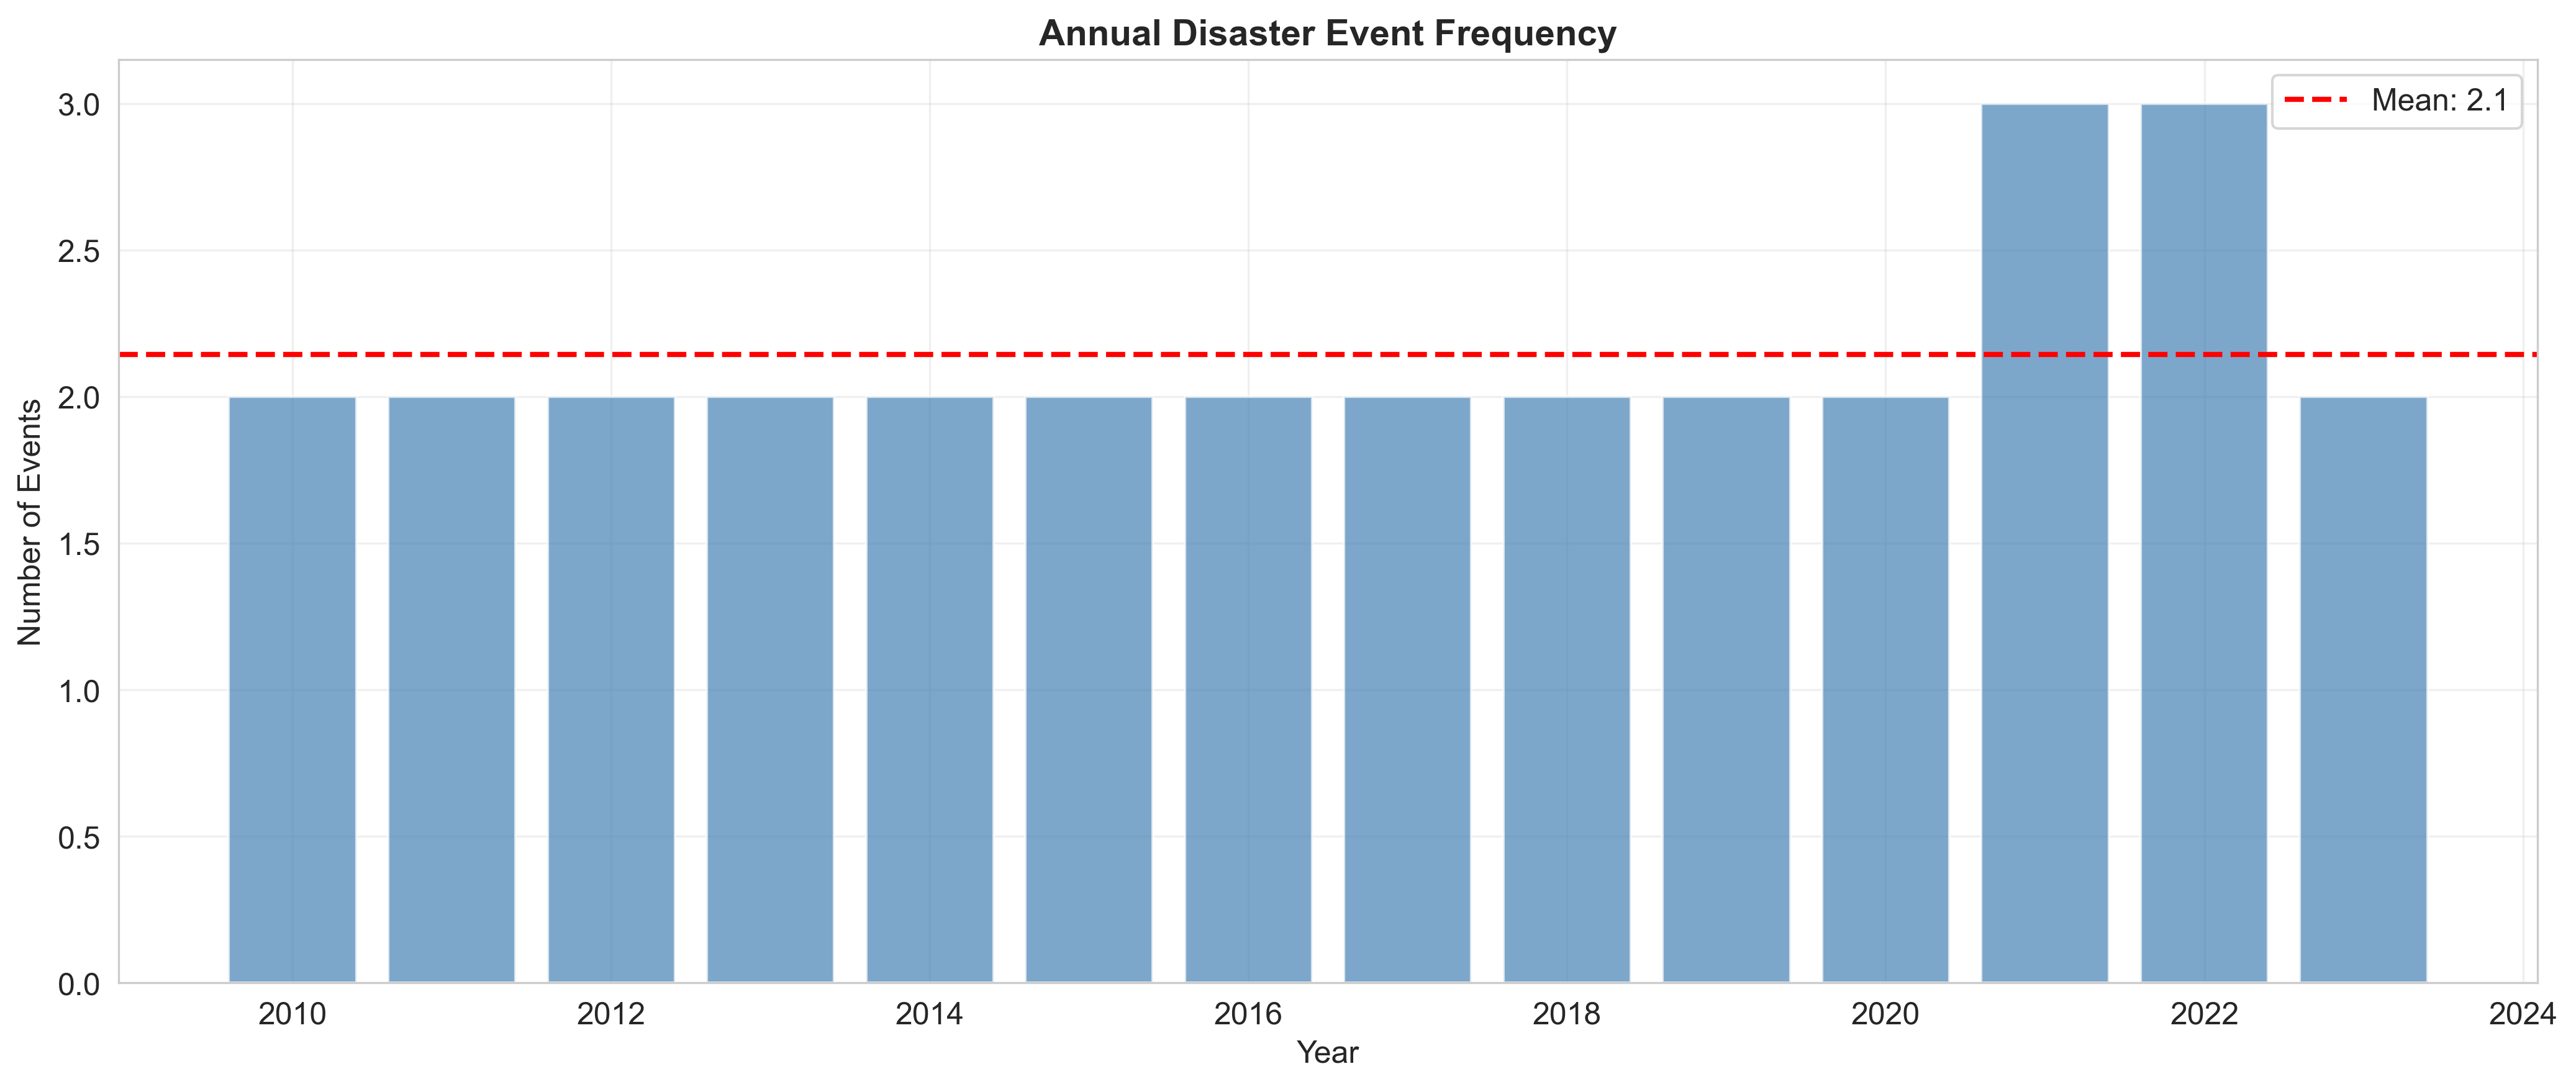

In [3]:
if df is not None:
    annual_freq = calculate_event_frequency_by_period(df, period='year')
    
    print("Annual Event Frequency Statistics:")
    print(f"  Mean: {annual_freq['event_count'].mean():.1f} events/year")
    print(f"  Median: {annual_freq['event_count'].median():.1f} events/year")
    print(f"  Std Dev: {annual_freq['event_count'].std():.1f}")
    print(f"  Min: {annual_freq['event_count'].min()} events/year")
    print(f"  Max: {annual_freq['event_count'].max()} events/year")
    
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(annual_freq['year'], annual_freq['event_count'], color='steelblue', alpha=0.7)
    ax.axhline(annual_freq['event_count'].mean(), color='red', linestyle='--', 
               linewidth=2, label=f"Mean: {annual_freq['event_count'].mean():.1f}")
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Number of Events', fontsize=12)
    ax.set_title('Annual Disaster Event Frequency', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '02_annual_frequency.png', dpi=300, bbox_inches='tight')
    plt.show()

## 3. Frequency by Hazard Type

In [4]:
if df is not None and 'hazardtype' in df.columns:
    hazard_freq = df['hazardtype'].value_counts().head(10)
    
    print("Top 10 Hazard Types by Frequency:")
    display(hazard_freq)
    
    years_covered = df['year'].max() - df['year'].min() + 1
    print(f"\nAverage Annual Frequency (top 10 hazards):")
    for hazard, count in hazard_freq.items():
        avg_annual = count / years_covered
        print(f"  {hazard}: {avg_annual:.2f} events/year")

Top 10 Hazard Types by Frequency:


hazardtype
FLOOD         11
DROUGHT        7
STORM          5
LANDSLIDE      2
FIRE           2
EARTHQUAKE     1
HEAVY RAIN     1
EPIDEMIC       1
Name: count, dtype: int64


Average Annual Frequency (top 10 hazards):
  FLOOD: 0.79 events/year
  DROUGHT: 0.50 events/year
  STORM: 0.36 events/year
  LANDSLIDE: 0.14 events/year
  FIRE: 0.14 events/year
  EARTHQUAKE: 0.07 events/year
  HEAVY RAIN: 0.07 events/year
  EPIDEMIC: 0.07 events/year


## 4. Temporal Trend Analysis

In [5]:
if df is not None:
    trends = analyze_temporal_trends(df, date_col='year')
    
    if 'trend_slope' in trends.columns:
        slope = trends['trend_slope'].iloc[0]
        r_squared = trends['trend_r_squared'].iloc[0]
        p_value = trends['trend_p_value'].iloc[0]
        
        print("Temporal Trend Analysis:")
        print(f"  Trend slope: {slope:.2f} events/year")
        print(f"  R-squared: {r_squared:.3f}")
        print(f"  P-value: {p_value:.4f}")
        
        if p_value < 0.05:
            if slope > 0:
                print(f"\n  ✓ Statistically significant INCREASING trend detected")
            else:
                print(f"\n  ✓ Statistically significant DECREASING trend detected")
        else:
            print(f"\n  No statistically significant trend detected (p > 0.05)")

Temporal Trend Analysis:
  Trend slope: 0.04 events/year
  R-squared: 0.256
  P-value: 0.0646

  No statistically significant trend detected (p > 0.05)


## 5. Seasonal Patterns

Monthly Event Frequency:


,month,event_count
0,1,3
1,2,3
2,3,3
3,4,4
4,5,4
5,6,1
6,7,2
7,8,2
8,9,2
9,10,2


2026-05-23 07:15:39,926 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-23 07:15:39,929 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


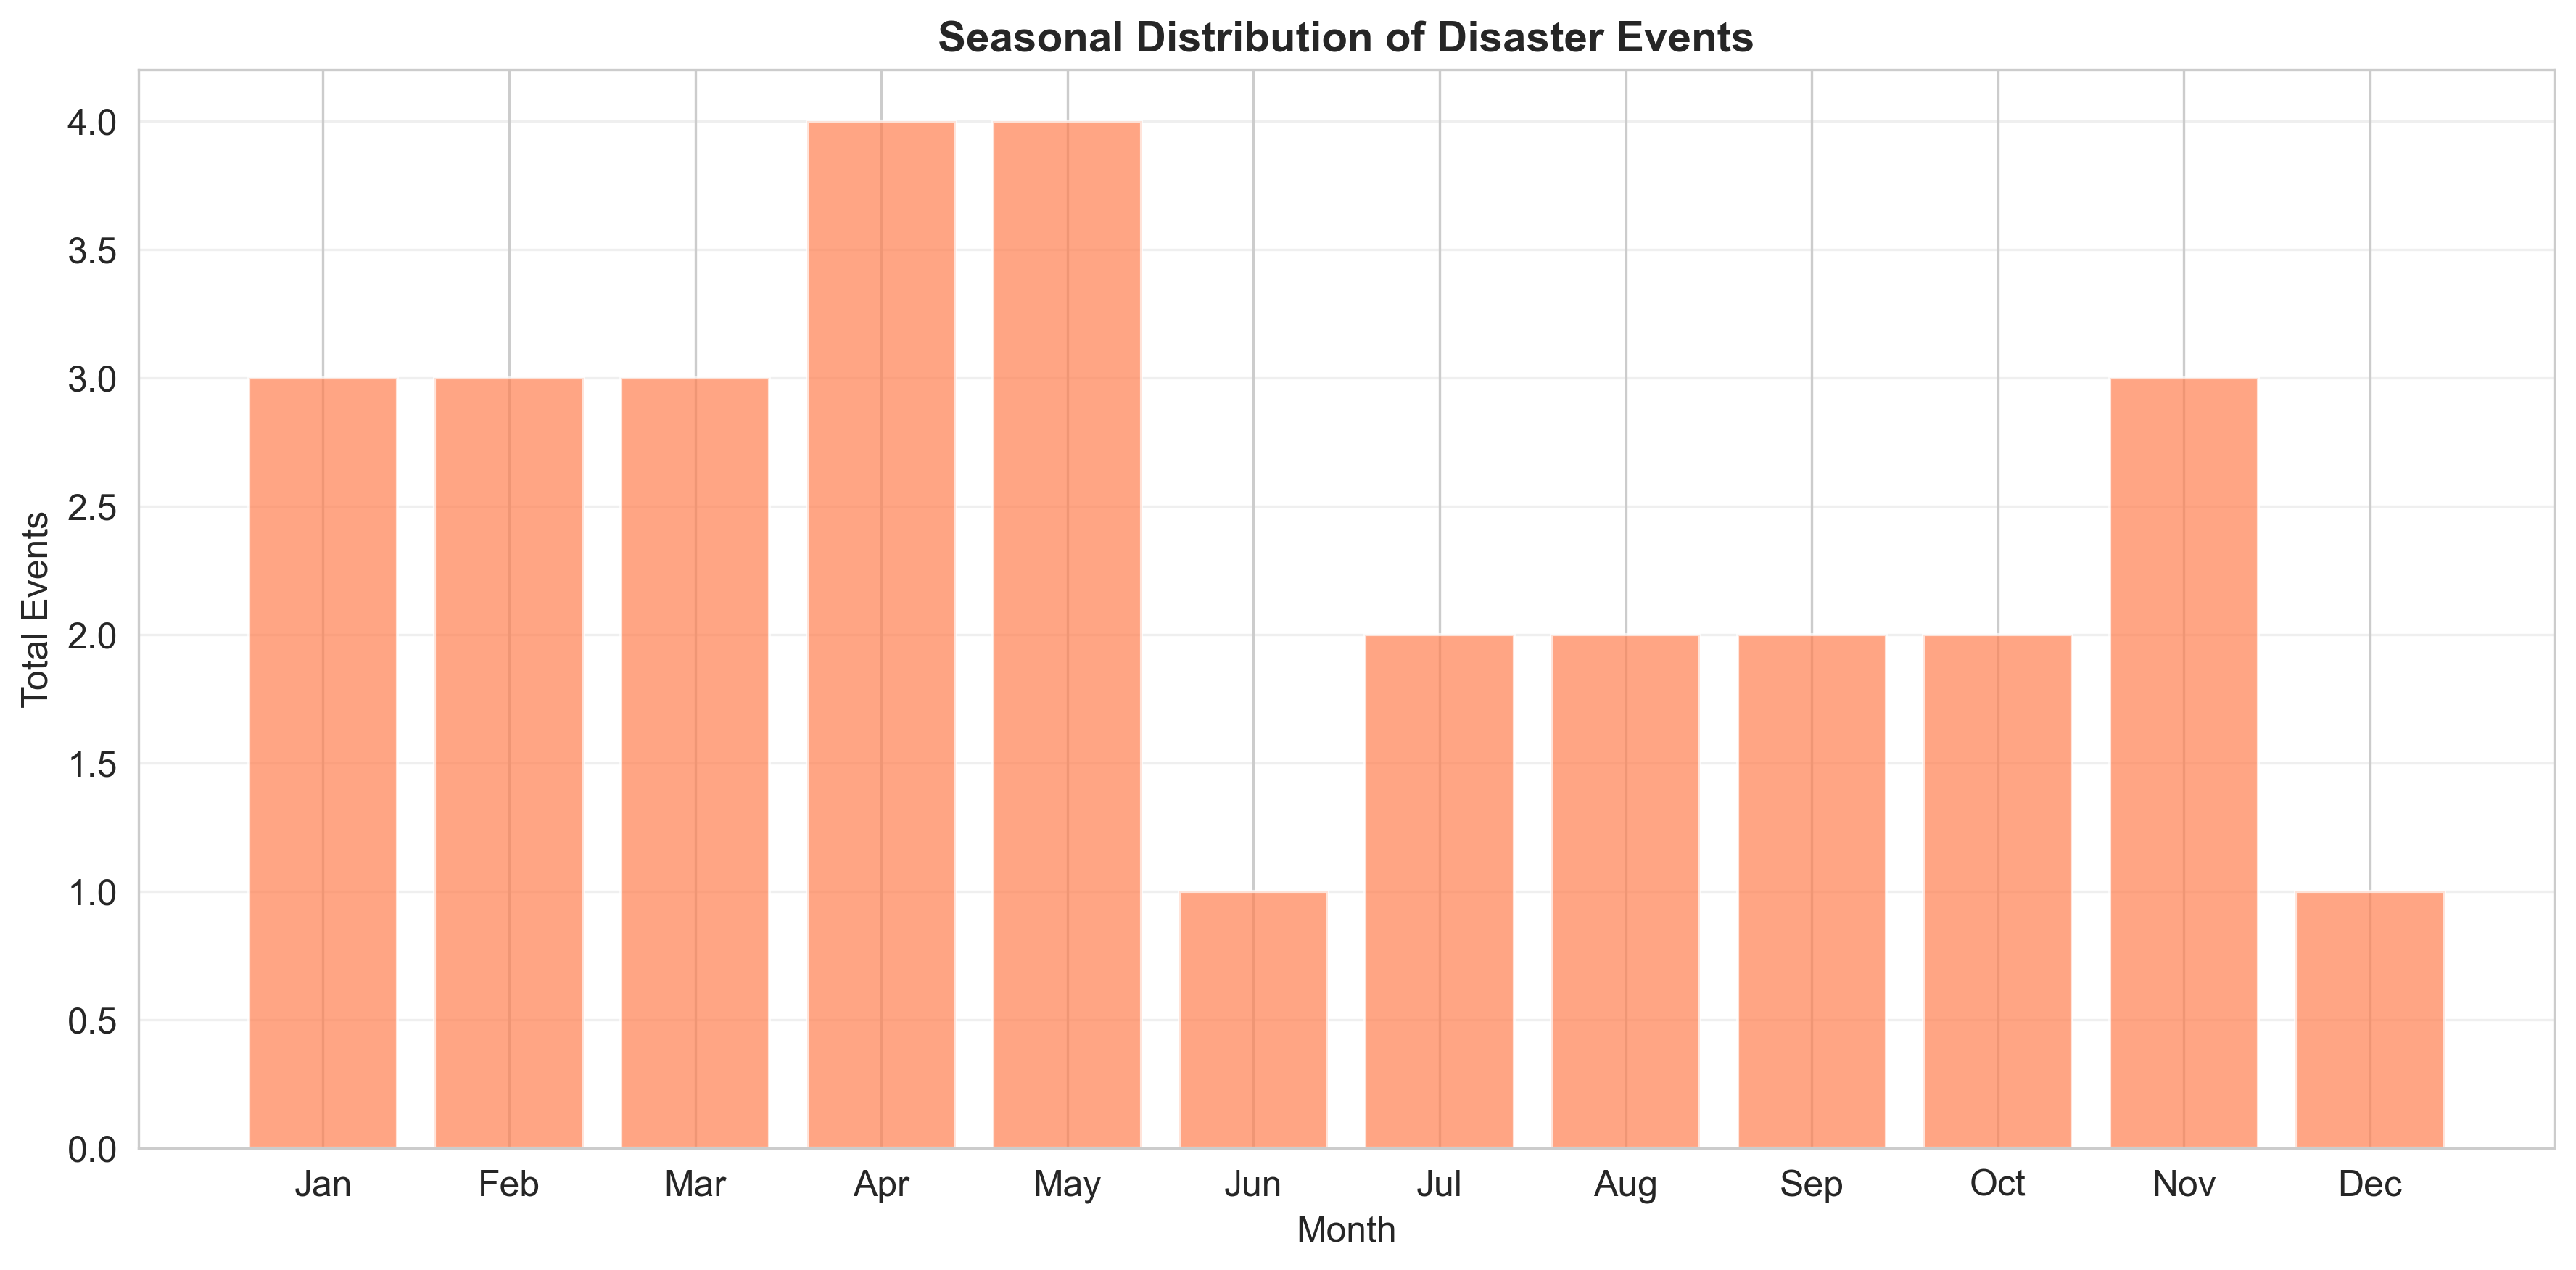

2026-05-23 07:15:42,590 - INFO - Figure saved to D:\Projects\sendai-multi-hazard-risk-modeling\outputs\figures\02_seasonal_heatmap.png


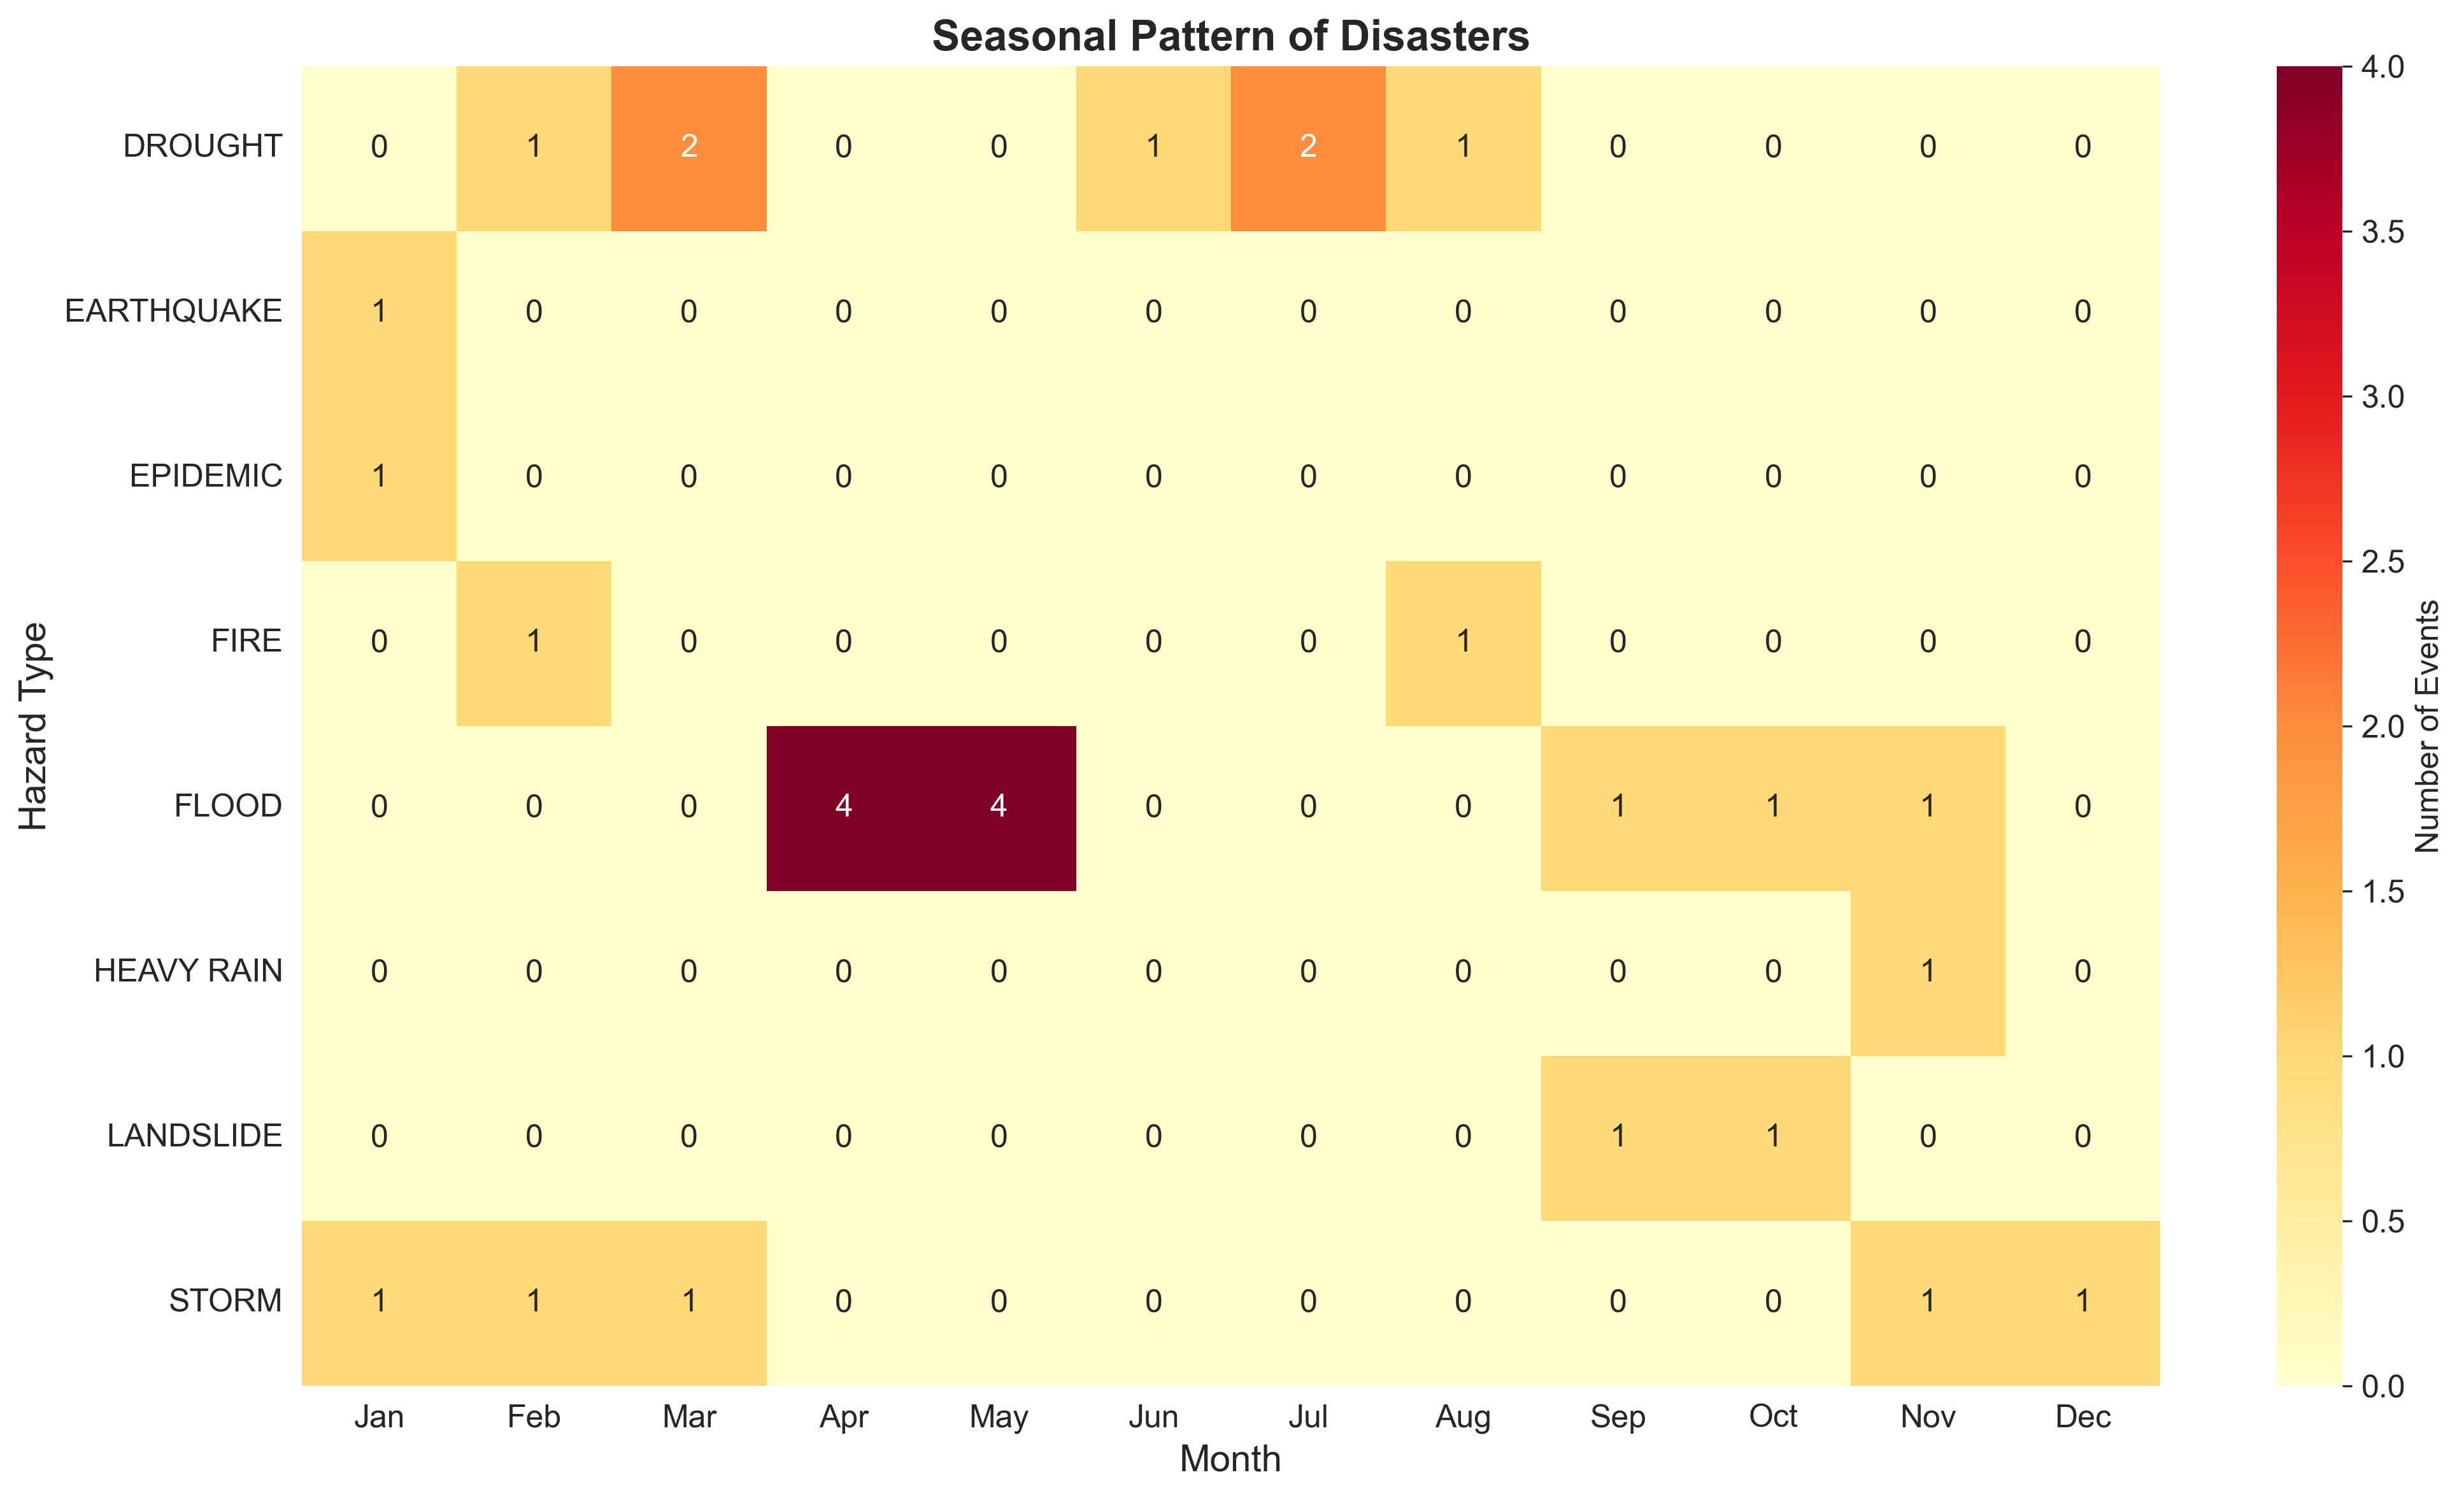

In [6]:
if df is not None and 'month' in df.columns:
    monthly_freq = calculate_event_frequency_by_period(df, period='month')
    
    print("Monthly Event Frequency:")
    display(monthly_freq)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    monthly_freq_sorted = monthly_freq.sort_values('month')
    x_labels = [month_names[int(m)-1] if m <= 12 else str(m) 
                for m in monthly_freq_sorted['month']]
    
    ax.bar(x_labels, monthly_freq_sorted['event_count'], color='coral', alpha=0.7)
    ax.set_xlabel('Month', fontsize=12)
    ax.set_ylabel('Total Events', fontsize=12)
    ax.set_title('Seasonal Distribution of Disaster Events', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '02_monthly_frequency.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    if 'hazardtype' in df.columns:
        fig = plot_seasonal_heatmap(df, save_path=FIGURES_DIR / '02_seasonal_heatmap.png')
        plt.show()

## 6. Probability Distribution Fitting

In [7]:
if df is not None:
    annual_counts = df.groupby('year').size()
    
    dist_results = fit_frequency_distribution(annual_counts, 
                                              distributions=['poisson', 'nbinom'])
    
    print("Probability Distribution Fitting Results:")
    print("="*60)
    
    if 'poisson' in dist_results:
        print("\nPoisson Distribution:")
        print(f"  Lambda (mean): {dist_results['poisson']['lambda']:.2f}")
        print(f"  Chi-square statistic: {dist_results['poisson']['chi2_statistic']:.2f}")
        print(f"  P-value: {dist_results['poisson']['p_value']:.4f}")
        print(f"  AIC: {dist_results['poisson']['aic']:.2f}")
        
        if dist_results['poisson']['p_value'] > 0.05:
            print("  ✓ Poisson distribution is a good fit (p > 0.05)")
        else:
            print("  ✗ Poisson distribution may not be ideal (p < 0.05)")
    
    if 'nbinom' in dist_results:
        print("\nNegative Binomial Distribution:")
        print(f"  n: {dist_results['nbinom']['n']:.2f}")
        print(f"  p: {dist_results['nbinom']['p']:.4f}")
        print(f"  Mean: {dist_results['nbinom']['mean']:.2f}")
        print(f"  Variance: {dist_results['nbinom']['variance']:.2f}")

Probability Distribution Fitting Results:

Poisson Distribution:
  Lambda (mean): 2.14
  Chi-square statistic: 4.32
  P-value: 0.0377
  AIC: 40.07
  ✗ Poisson distribution may not be ideal (p < 0.05)


## 7. Return Period Analysis

In [8]:
if df is not None and 'hazardtype' in df.columns:
    print("Return Period Analysis for Major Events:")
    print("="*60)
    
    top_hazards = df['hazardtype'].value_counts().head(5).index
    
    thresholds = {
        'deaths': [10, 100, 1000],
        'total_affected': [1000, 10000, 100000]
    }
    
    for hazard in top_hazards:
        print(f"\n{hazard}:")
        
        if 'total_deaths' in df.columns:
            for threshold in thresholds['deaths']:
                return_period = calculate_return_period(df, hazard, 'total_deaths', threshold)
                if not np.isnan(return_period) and return_period != np.inf:
                    print(f"  Deaths ≥ {threshold}: {return_period:.1f} year return period")
        
        if 'total_affected' in df.columns:
            for threshold in thresholds['total_affected']:
                return_period = calculate_return_period(df, hazard, 'total_affected', threshold)
                if not np.isnan(return_period) and return_period != np.inf:
                    print(f"  Affected ≥ {threshold}: {return_period:.1f} year return period")

Return Period Analysis for Major Events:

FLOOD:
  Deaths ≥ 10: 1.3 year return period
  Deaths ≥ 100: 1.8 year return period
  Affected ≥ 1000: 1.3 year return period
  Affected ≥ 10000: 1.3 year return period
  Affected ≥ 100000: 1.3 year return period

DROUGHT:
  Deaths ≥ 10: 1.9 year return period
  Deaths ≥ 100: 1.9 year return period
  Deaths ≥ 1000: 4.3 year return period
  Affected ≥ 1000: 1.9 year return period
  Affected ≥ 10000: 1.9 year return period
  Affected ≥ 100000: 1.9 year return period

STORM:
  Deaths ≥ 10: 2.4 year return period
  Deaths ≥ 100: 12.0 year return period
  Affected ≥ 1000: 2.4 year return period
  Affected ≥ 10000: 2.4 year return period
  Affected ≥ 100000: 6.0 year return period

LANDSLIDE:
  Deaths ≥ 10: 2.0 year return period
  Deaths ≥ 100: 4.0 year return period
  Affected ≥ 1000: 2.0 year return period
  Affected ≥ 10000: 2.0 year return period

FIRE:
  Deaths ≥ 10: 7.0 year return period
  Affected ≥ 1000: 3.5 year return period
  Affected ≥ 

## 8. Frequency by Geographic Location

Top 15 Locations by Event Frequency:


level2
Nairobi          3
Rift Valley      2
Western          2
Eastern          2
Addis Ababa      1
Central          1
Afar             1
Bay              1
Banadir          1
Kagera           1
Dar es Salaam    1
Coast            1
Kilimanjaro      1
Mwanza           1
Nampula          1
dtype: int64

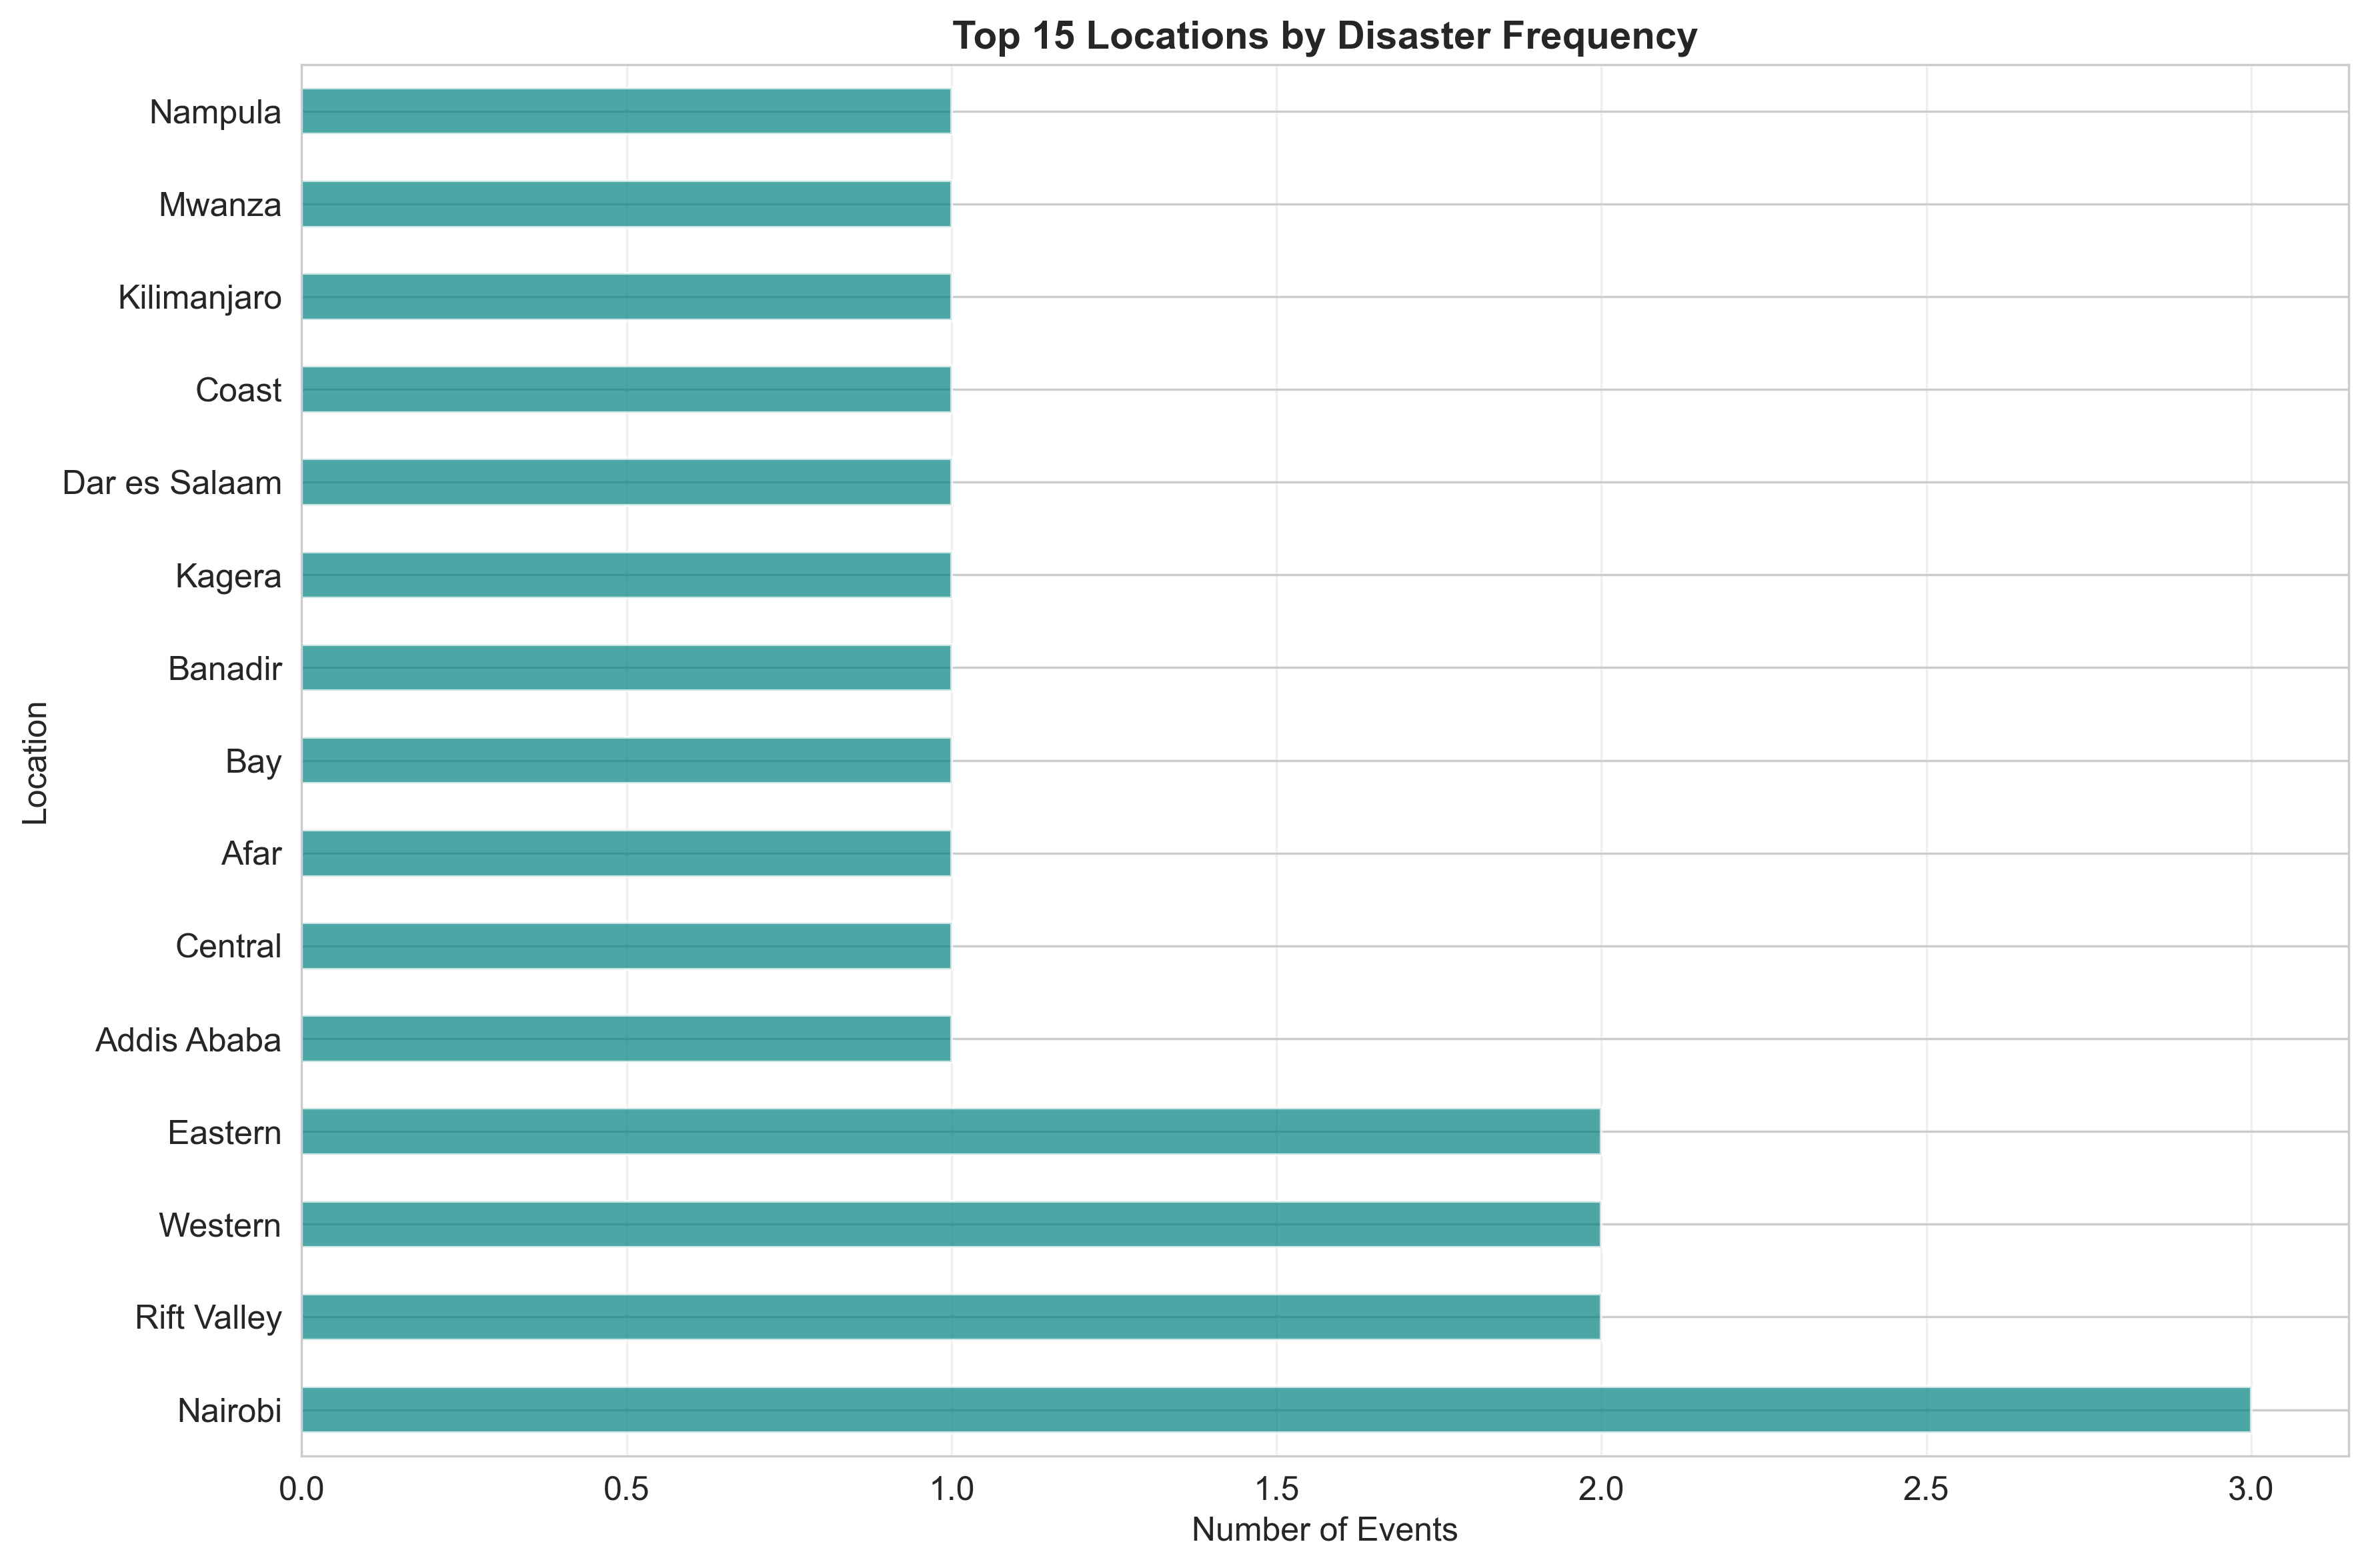

In [9]:
if df is not None and 'level2' in df.columns:
    location_freq = df.groupby('level2').size().sort_values(ascending=False).head(15)
    
    print("Top 15 Locations by Event Frequency:")
    display(location_freq)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    location_freq.plot(kind='barh', ax=ax, color='teal', alpha=0.7)
    ax.set_xlabel('Number of Events', fontsize=12)
    ax.set_ylabel('Location', fontsize=12)
    ax.set_title('Top 15 Locations by Disaster Frequency', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '02_location_frequency.png', dpi=300, bbox_inches='tight')
    plt.show()

## 9. Multi-Hazard Frequency Analysis

Locations with Highest Hazard Diversity:


level2
Eastern          2
Rift Valley      2
Western          2
Nairobi          2
Addis Ababa      1
Central          1
Afar             1
Bay              1
Banadir          1
Kagera           1
Dar es Salaam    1
Coast            1
Kilimanjaro      1
Mwanza           1
Nampula          1
Name: hazardtype, dtype: int64

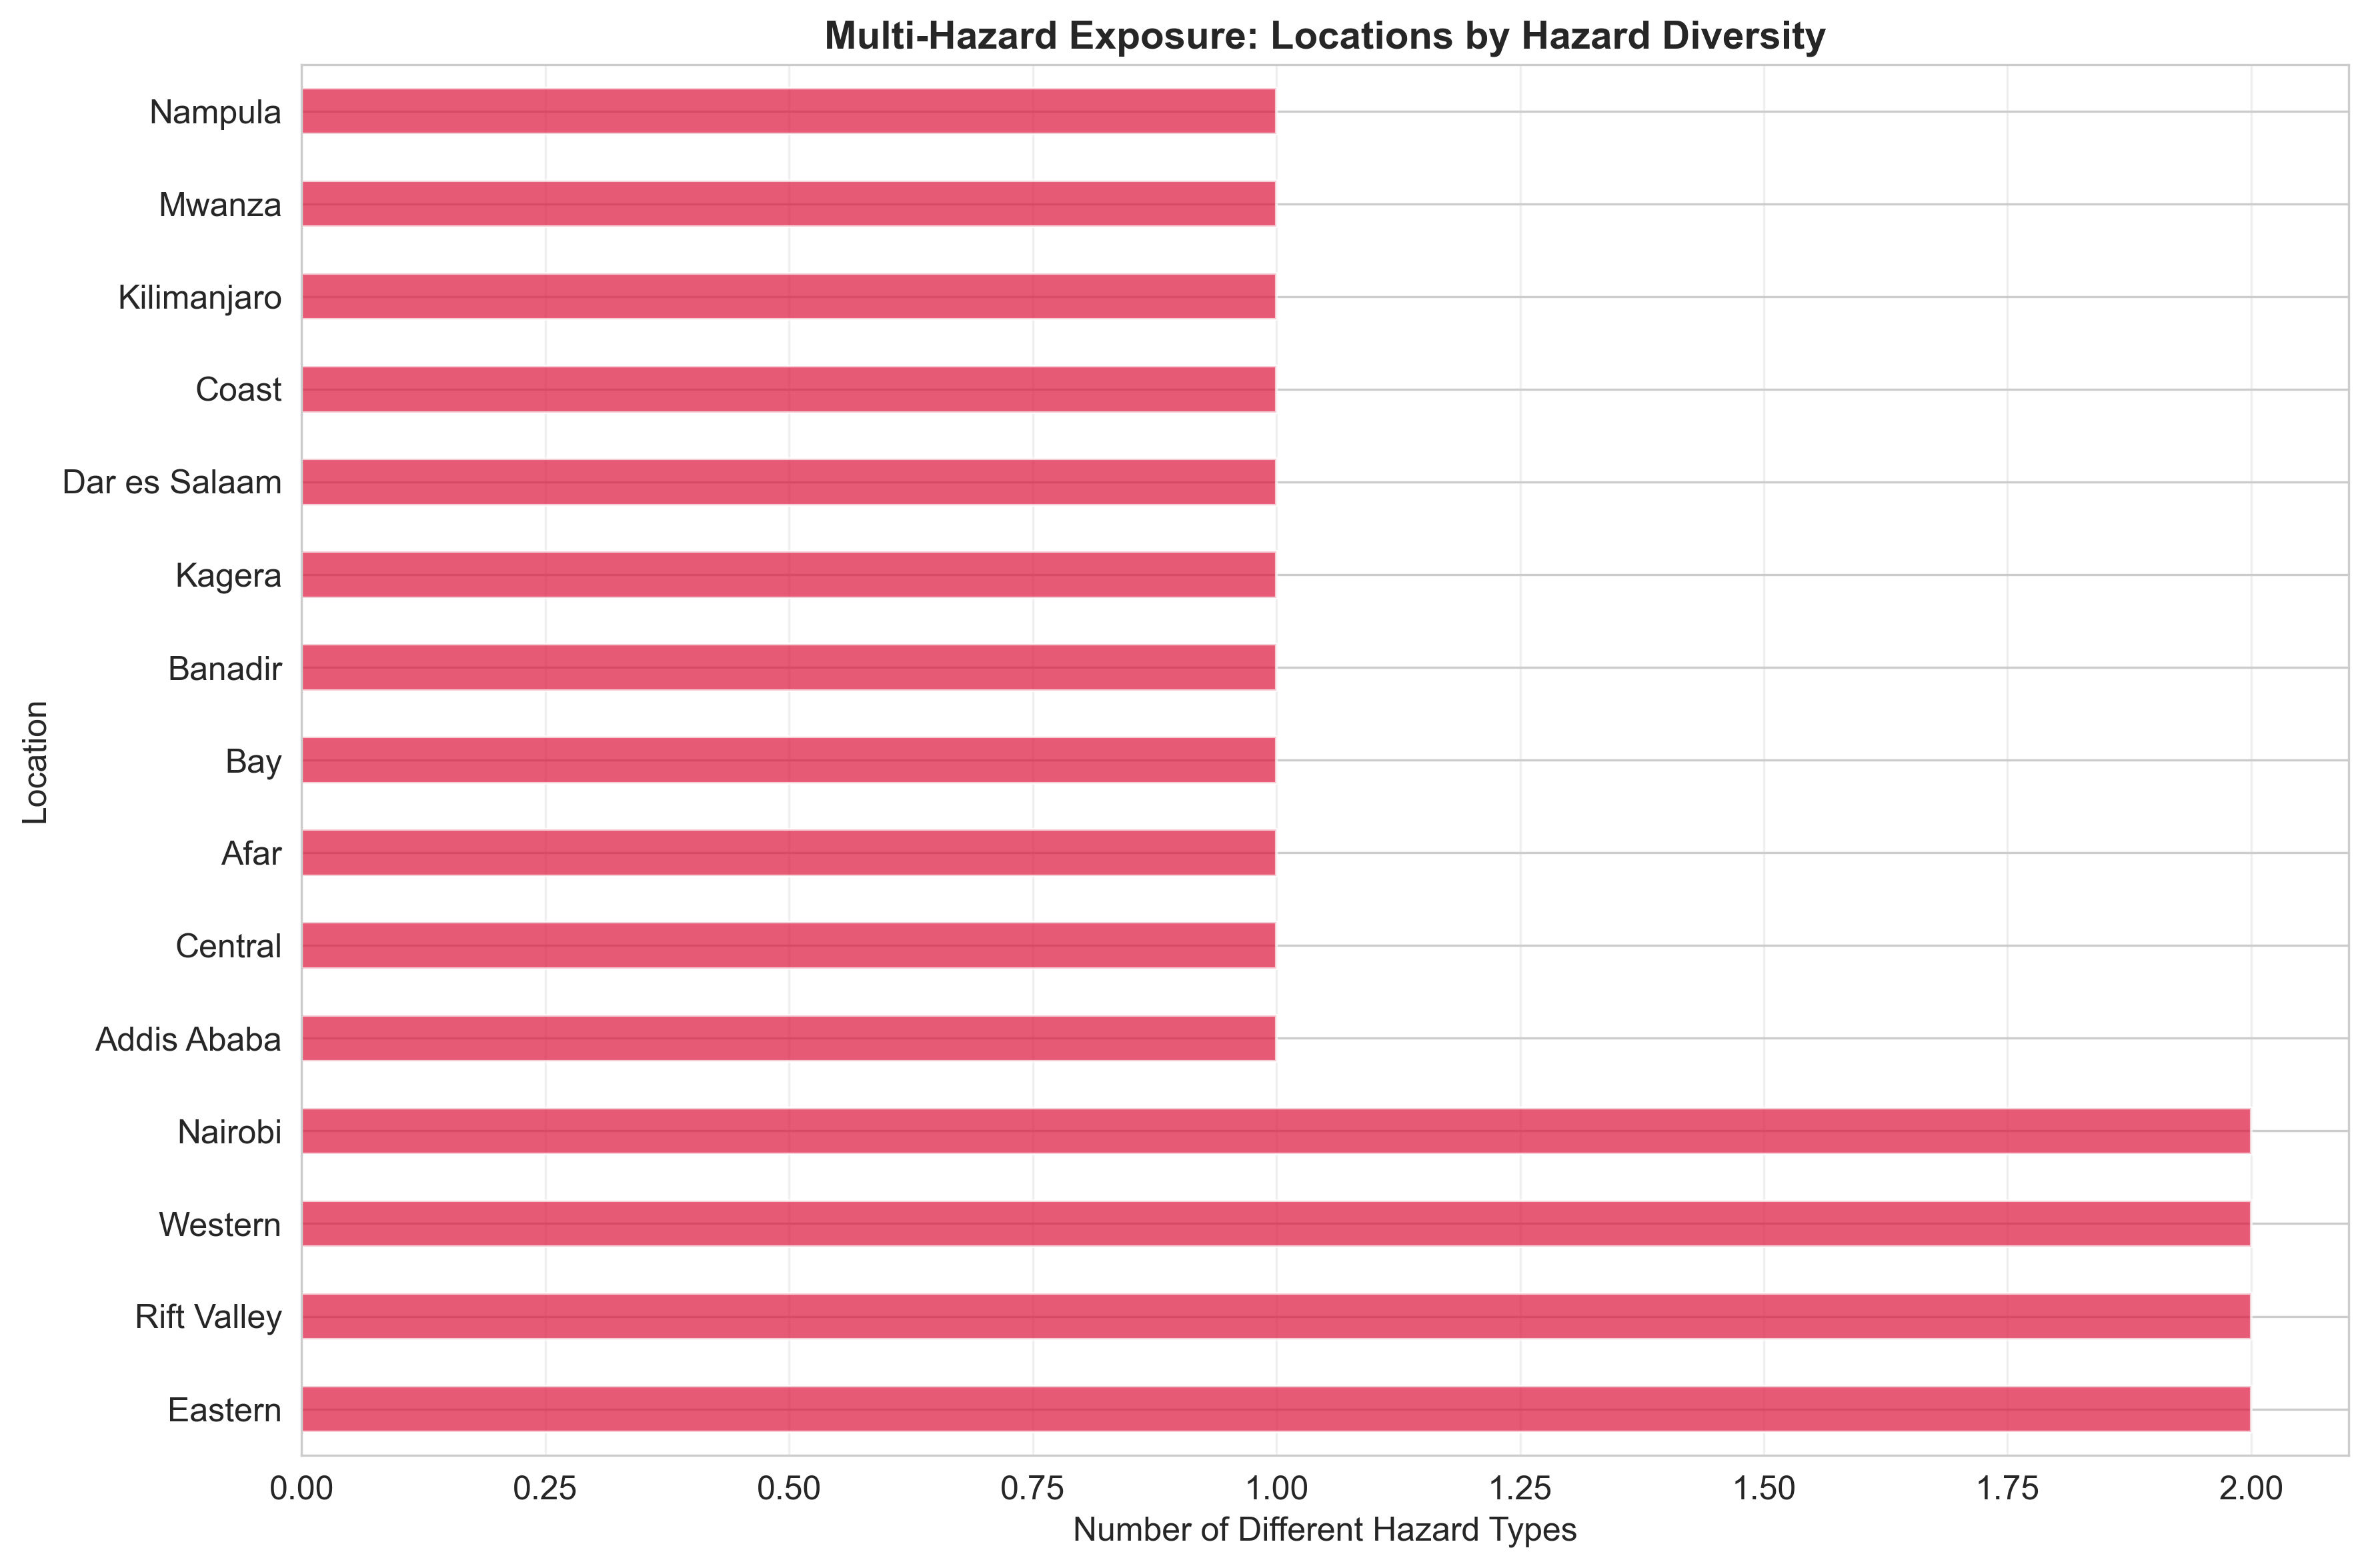

In [10]:
if df is not None and 'level2' in df.columns and 'hazardtype' in df.columns:
    multi_hazard = df.groupby('level2')['hazardtype'].nunique().sort_values(ascending=False).head(15)
    
    print("Locations with Highest Hazard Diversity:")
    display(multi_hazard)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    multi_hazard.plot(kind='barh', ax=ax, color='crimson', alpha=0.7)
    ax.set_xlabel('Number of Different Hazard Types', fontsize=12)
    ax.set_ylabel('Location', fontsize=12)
    ax.set_title('Multi-Hazard Exposure: Locations by Hazard Diversity', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '02_multi_hazard_diversity.png', dpi=300, bbox_inches='tight')
    plt.show()

## 10. Summary and Key Findings

In [11]:
if df is not None:
    print("="*80)
    print("FREQUENCY ANALYSIS SUMMARY")
    print("="*80)
    
    annual_counts = df.groupby('year').size()
    print(f"\n📊 Event Frequency:")
    print(f"   - Average: {annual_counts.mean():.1f} events/year")
    print(f"   - Trend: {'Increasing' if slope > 0 else 'Decreasing'} "
          f"({abs(slope):.2f} events/year)")
    
    if 'month' in df.columns:
        peak_month = df['month'].mode()[0]
        month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        print(f"\n📅 Seasonal Patterns:")
        print(f"   - Peak month: {month_names[int(peak_month)-1] if peak_month <= 12 else peak_month}")
    
    if 'hazardtype' in df.columns:
        most_frequent = df['hazardtype'].value_counts().index[0]
        print(f"\n⚠️  Most Frequent Hazard:")
        print(f"   - {most_frequent}")
    
    print(f"\n📈 Next Steps:")
    print("   1. Proceed to severity analysis (notebook 03)")
    print("   2. Analyze impact magnitudes and severity classifications")
    print("   3. Identify extreme events and outliers")

FREQUENCY ANALYSIS SUMMARY

📊 Event Frequency:
   - Average: 2.1 events/year
   - Trend: Increasing (0.04 events/year)

📅 Seasonal Patterns:
   - Peak month: Apr

⚠️  Most Frequent Hazard:
   - FLOOD

📈 Next Steps:
   1. Proceed to severity analysis (notebook 03)
   2. Analyze impact magnitudes and severity classifications
   3. Identify extreme events and outliers
